In [1]:
import re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from nltk.stem import PorterStemmer

In [4]:
train = pd.read_csv(r"C:\Users\Pritika\OneDrive\mds\imdb_train.csv")
test = pd.read_csv(r"C:\Users\Pritika\OneDrive\mds\imdb_test.csv")
print(train.shape, test.shape)
train.head()

(25000, 2) (25000, 2)


,text,label
0,In Panic In The Streets Richard Widmark plays ...,1
1,If you ask me the first one was really better ...,0
2,I am a big fan a Faerie Tale Theatre and I've ...,1
3,I just finished reading a book about Dillinger...,0
4,Greg Davis and Bryan Daly take some crazed sta...,0


In [5]:
stemmer = PorterStemmer()
STOPWORDS = ENGLISH_STOP_WORDS

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", ' ', text)
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

train['clean'] = train['text'].apply(clean_text)
test['clean'] = test['text'].apply(clean_text)
print("done")

done


In [6]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=5)
X_train = tfidf.fit_transform(train['clean'])
X_test = tfidf.transform(test['clean'])
y_train, y_test = train['label'], test['label']

nb = MultinomialNB()
nb.fit(X_train, y_train)
preds = nb.predict(X_test)
probs = nb.predict_proba(X_test)[:,1]

In [7]:
print("Accuracy: ", round(accuracy_score(y_test, preds), 4))
print("Precision:", round(precision_score(y_test, preds), 4))
print("Recall:   ", round(recall_score(y_test, preds), 4))
print("F1:       ", round(f1_score(y_test, preds), 4))
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds, target_names=['negative','positive']))

Accuracy:  0.8422
Precision: 0.8492
Recall:    0.8323
F1:        0.8407
[[10652  1848]
 [ 2096 10404]]
              precision    recall  f1-score   support

    negative       0.84      0.85      0.84     12500
    positive       0.85      0.83      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



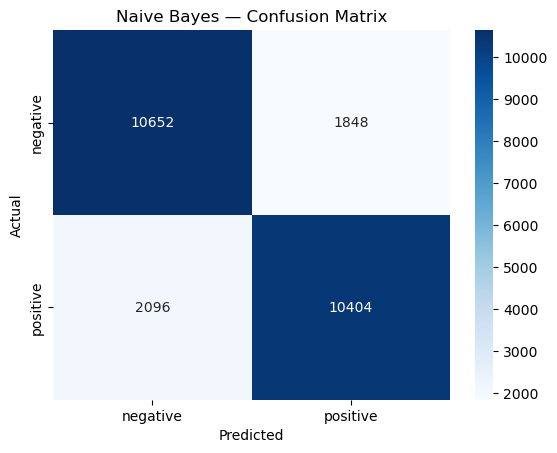

In [8]:
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','positive'], yticklabels=['negative','positive'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Naive Bayes — Confusion Matrix')
plt.show()

In [9]:
feature_names = np.array(tfidf.get_feature_names_out())
diff = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
top_pos = np.argsort(diff)[-15:][::-1]
top_neg = np.argsort(diff)[:15]
print("POSITIVE:", list(feature_names[top_pos]))
print("NEGATIVE:", list(feature_names[top_neg]))

POSITIVE: ['edi', 'antwon', 'goldsworthi', 'matthau', 'gundam', 'highli recommend', 'nanci drew', 'victoria', 'cast excel', 'din', 'felix', 'gunga', 'vanc', 'excel movi', 'gunga din']
NEGATIVE: ['worst movi', 'worst film', 'wast time', 'don wast', 'wast money', 'avoid cost', 'piec crap', 'boll', 'worst', 'act horribl', 'hour life', 'wast', 'seagal', 'total wast', 'unfunni']


In [10]:
errors = test.copy()
errors['pred'] = preds
errors['prob_positive'] = probs
wrong = errors[errors['label'] != errors['pred']]
print(f"Misclassified: {len(wrong)} / {len(test)} ({len(wrong)/len(test):.2%})")

wrong['gap'] = abs(wrong['prob_positive'] - 0.5)
top_err = wrong.sort_values('gap', ascending=False).head(3)
for i, row in top_err.iterrows():
    print(f"True:{row['label']} Pred:{row['pred']} P(pos)={row['prob_positive']:.2f}")
    print(row['text'][:250], "\n")

Misclassified: 3944 / 25000 (15.78%)
True:1 Pred:0 P(pos)=0.03
Right, here we go, you have probably read in previous reviews on this film that it is awful, badly acted, avoid at all costs. Well i suppose in some ways this is true, it is fair to say that you couldn't write a spoiler in this comment as there is no 

True:1 Pred:0 P(pos)=0.04
Do-It-Yourself indie horror auteur Todd Sheets returns with another entertainingly atrocious nickel'n'dime shot-on-video clunker that's basically just a feeble excuse to sling around a lot of watery blood and gleaming guts as often as possible. An ev 

True:1 Pred:0 P(pos)=0.04
I am a glutton for B-movies. I love the old Drive-In fare like this movie. This film, made for very little money it seems, does do one thing that some bigger budgeted films fail. It is cheezy. It is gory. It has no real plot, but it entertained me fo 



C:\Users\Pritika\AppData\Local\Temp\ipykernel_23036\483856443.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wrong['gap'] = abs(wrong['prob_positive'] - 0.5)


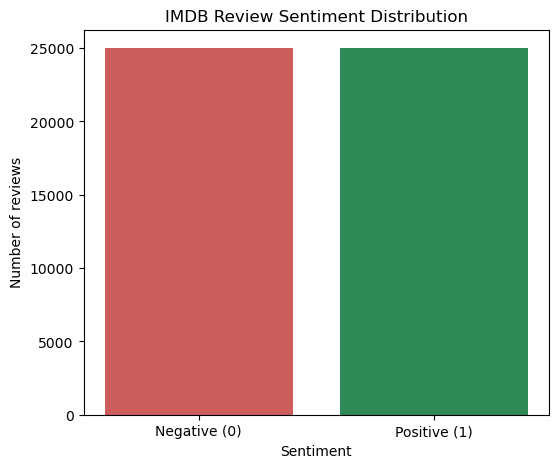

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

counts = pd.concat([train, test])['label'].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(['Negative (0)', 'Positive (1)'], counts.values, color=['indianred', 'seagreen'])
plt.xlabel('Sentiment')
plt.ylabel('Number of reviews')
plt.title('IMDB Review Sentiment Distribution')
plt.show()